## Logistic Regression: end-to-end



---
## Logistic regression intuition

Logistic regression is a **linear model** that outputs a **probability between 0 and 1**.

Main steps:
- Compute a linear score: \(z = b_0 + b_1 x_1 + \dots + b_d x_d\)
- Pass \(z\) through the sigmoid function to turn it into a probability:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

We then choose a **threshold** (for example 0.5):
- if probability ≥ threshold → predict class 1
- else → predict class 0

Internally, logistic regression is linear in the **log-odds**, but for now it is enough to remember:

> It finds a linear boundary that separates the two classes and gives a probability for each point.


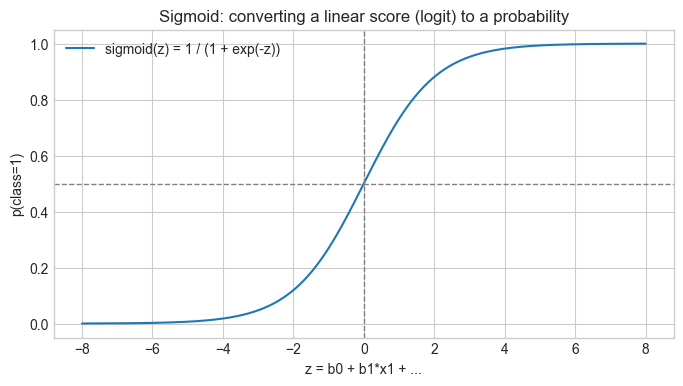

threshold=0.3 -> proba=[0.12 0.49 0.5  0.73 0.91] -> pred=[0 1 1 1 1]
threshold=0.5 -> proba=[0.12 0.49 0.5  0.73 0.91] -> pred=[0 0 1 1 1]
threshold=0.7 -> proba=[0.12 0.49 0.5  0.73 0.91] -> pred=[0 0 0 1 1]


In [41]:
import numpy as np
import matplotlib.pyplot as plt
# Visualize the sigmoid and how thresholds map probabilities -> classes
z = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z))
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, label="sigmoid(z) = 1 / (1 + exp(-z))")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0.0, color="gray", linestyle="--", linewidth=1)
plt.title("Sigmoid: converting a linear score (logit) to a probability")
plt.xlabel("z = b0 + b1*x1 + ...")
plt.ylabel("p(class=1)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()
# Example: turning probabilities into hard class predictions via a threshold
example_proba = np.array([0.12, 0.49, 0.50, 0.73, 0.91])
for t in [0.3, 0.5, 0.7]:
    preds = (example_proba >= t).astype(int)
    print(f"threshold={t:.1f} -> proba={example_proba} -> pred={preds}")


---
## Step 0: importing the libraries

We will use a small set of standard Python libraries:
- `numpy` and `pandas` for working with data
- `matplotlib` for simple plots
- `scikit-learn` (`sklearn`) for datasets, splitting, preprocessing, models, and metrics

You do not need to memorize every import; just recognise the groups: **data**, **plotting**, and **machine learning**.


In [42]:
# --- Import necessary numerical and data manipulation libraries ---
import numpy as np             # NumPy for fast array and mathematical operations
import pandas as pd            # Pandas for handling tabular data (DataFrames)
import matplotlib.pyplot as plt  # Matplotlib for generating plots and charts
# Import display function to format outputs beautifully in Jupyter
from IPython.display import display
# --- Import scikit-learn components ---
# 1. Dataset generation
from sklearn.datasets import load_iris
# 2. Splitting data into training and test sets
from sklearn.model_selection import train_test_split
# 3. Building machine learning pipelines
from sklearn.pipeline import Pipeline
# 4. Feature scaling standardizer (mean=0, variance=1)
from sklearn.preprocessing import StandardScaler
# 5. Logistic Regression models (standard and with cross-validation)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
# 6. Evaluation metrics for classification performance
from sklearn.metrics import (
    accuracy_score,         # Overall correctness
    precision_score,        # Quality of positive predictions
    recall_score,           # Ability to find positive instances
    f1_score,               # Harmonic mean of precision and recall
    roc_auc_score,          # Area under ROC curve (distinction between classes)
    confusion_matrix,       # Matrix of true vs false predictions
    ConfusionMatrixDisplay, # Visual representation of the confusion matrix
)
# Try configuring Matplotlib to use a nice visual style
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot") # Fallback style if seaborn is unavailable
# Configure pandas to show up to 50 columns without truncating them
pd.set_option("display.max_columns", 50)


---
## 1️⃣ The Problem & The Data (Classification)

**💡 Concept:** In **classification**, the target is a **category** (0/1, spam/not spam, yes/no), not a continuous number.

We’ll use the built-in **Iris** dataset, but we’ll keep only **two species** to make this a clean **binary classification** problem:
- **Class 0:** Setosa
- **Class 1:** Versicolor

**Features (X):** flower measurements (in cm)



In [43]:
# 1. Load the Iris dataset as a DataFrame
iris = load_iris(as_frame=True)
df = iris.frame.copy()
# 2. Filter for binary classification (Classes 0 and 1 only)
df = df[df['target'].isin([0, 1])].copy()
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor'})
# 3. Separate features (X) and target (y)
X_df = df.drop(columns=['target', 'species'])
y = df['target']
# 4. Check the dataset size and balance
print(f"Total Rows: {df.shape[0]} | Features: {X_df.shape[1]}")
print("\nClass Balance:")
print(y.value_counts().rename(index={0: "Setosa (0)", 1: "Versicolor (1)"}))
display(df.head())


Total Rows: 100 | Features: 4

Class Balance:
target
Setosa (0)        50
Versicolor (1)    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---
## Why this dataset often gives 1.0 (100%) later

In this notebook we first use **Iris (Setosa vs Versicolor)** because it’s easy to visualize.

**Important:** these two classes are *almost perfectly separable* using petal measurements, so **after we train Logistic Regression later**, you’ll often see Accuracy / Precision / Recall / F1 / ROC-AUC all come out as **1.0**.

That does **not** mean logistic regression is “magic” — it mostly means this particular slice of Iris is very clean.

Before we model, let’s quickly plot two features and visually confirm there’s a big gap (so a linear decision boundary can separate them).

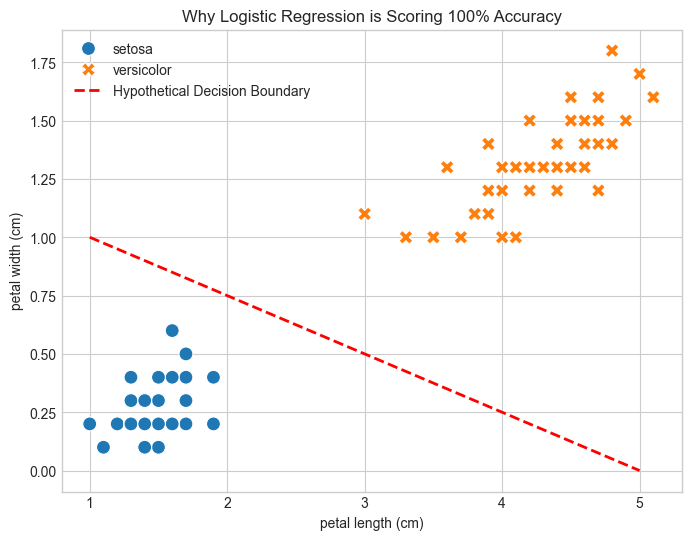

In [44]:
import seaborn as sns
# Let's map out the relationship between two random features like Petal Length and Petal Width
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',    # Color by class (setosa vs versicolor)
    style='species',
    s=100             # Dot size 
)
# # Draw a rough hypothetical "Decision Boundary" completely by hand to show the gap
# # [1.0, 5.0] -> These are the Starting and Ending X-coordinates
# # [1.0, 0.0] -> These are the Starting and Ending Y-coordinates
# # 'r--'      -> Shorthand to color the line Red ('r') and make it Dashed ('--')
# # lw=2       -> LineWidth: Make the plot line thicker
# # label      -> Registers the specific text for this line in the plot legend UI
plt.plot([1.0, 5.0], [1.0, 0.0], 'r--', lw=2, label="Hypothetical Decision Boundary")
plt.title("Why Logistic Regression is Scoring 100% Accuracy")
plt.legend()
plt.show()


---
## 🧾 Understanding the Iris columns (features)

All 4 columns are **simple flower measurements (in cm)**.

### The 4 features
- **sepal length (cm)**: length of the sepal (outer leaf-like part)
- **sepal width (cm)**: width of the sepal
- **petal length (cm)**: length of the petal (inner colored part)
- **petal width (cm)**: width of the petal

**💡 Intuition:** Petal measurements often separate species very clearly.

### Target meaning (for this notebook)
We keep only two species to make it binary:
- **0 = setosa**
- **1 = versicolor**


---
## 2️⃣ Train/Test Split & Baseline (The "Dumb" Model)

**💡 Concept:** Before building ML, create a baseline.

For classification, a simple baseline is:
- **Always predict the majority class** (most common label).

If your model can’t beat that, it’s not useful.


In [45]:
# Split data into 80% training data and 20% test data
# stratify=y ensures both training and test sets maintain the original 50/50 class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)
# Output the number of samples placed in the training vs testing blocks
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
# Create a baseline prediction strategy that simply guesses the most frequent class in the training set
majority_class = int(y_train.value_counts().idxmax())
# Generate an array matching test set dimensions filled identically with the majority class value
baseline_pred = np.full(shape=y_test.shape, fill_value=majority_class)
# Calculate evaluate metrics for our "dumb" baseline rule
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
# Display the baseline results
print(f"Majority class (from train): {majority_class}")
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Baseline F1: {baseline_f1:.3f}")


Training samples: 80, Test samples: 20
Majority class (from train): 0
Baseline Accuracy: 0.500
Baseline F1: 0.000


---
## 3️⃣ Logistic Regression Model

Despite the name, **Logistic Regression** is used for **classification**.

**Core idea:** It predicts a **probability** (between 0 and 1):

\[
P(y=1 \mid x) = \sigma(w^T x + b) \quad \text{where } \sigma(z)=\frac{1}{1+e^{-z}}
\]

Then we choose a threshold (often 0.5):
- if probability ≥ threshold → predict class 1
- else → predict class 0


Test-set metrics (threshold = 0.5)
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000


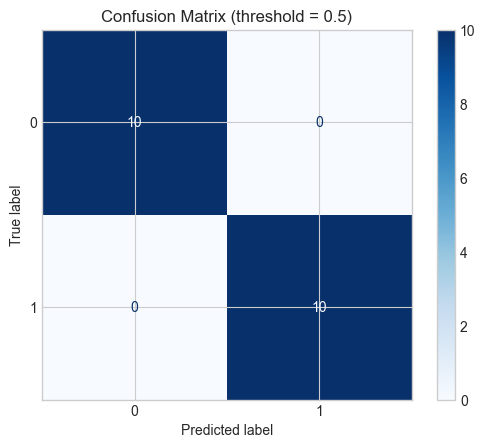

In [46]:
# Define an ML Pipeline: Data Scaling followed by Logistic Regression Training
log_reg_model = Pipeline([
    # Step 1: Standardize features (mean=0, variance=1) since Logistic Regression is sensitive to data scale
    ("scaler", StandardScaler()),
    # Step 2: Initialize the actual classification model
    (
        "logreg",
        LogisticRegression(
            max_iter=2000,  # Increase maximum iterations to ensure the optimization algorithm reliably converges
            random_state=42, # Fix the random seed to ensure results remain consistent across runs
        ),
    ),
])
# Train both the scaler and the logistic regression model on the training data
log_reg_model.fit(X_train, y_train)
# Step 3: Run the trained model against the unseen test data
# Logistic Regression natively predicts probabilities between 0 and 1.
# predict_proba() returns probabilities for [Class 0, Class 1]. We slice [:, 1] to grab only Class 1 probabilities.
y_proba = log_reg_model.predict_proba(X_test)[:, 1]
# y_proba_0 = log_reg_model.predict_proba(X_test)[:, 0]
# model.predict() always strictly uses 0.5 as its hardcoded threshold.
# To assign a custom threshold, we apply logic directly against the probabilities.
# For example, we'll use a standard 0.5 threshold here just like predict() does:
chosen_threshold = 0.5
y_pred = (y_proba >= chosen_threshold).astype(int)
# Step 4: Calculate evaluation metrics based on predictions vs true labels
acc = accuracy_score(y_test, y_pred)       # Fraction of predictions that were completely correct
prec = precision_score(y_test, y_pred)     # Out of all predicted class 1s, what fraction were actually class 1
rec = recall_score(y_test, y_pred)         # Out of all actual class 1s, what fraction were correctly detected
f1 = f1_score(y_test, y_pred)              # Harmonic balance combining Precision and Recall
roc_auc = roc_auc_score(y_test, y_proba)   # Area under curve measuring class separability
# Print evaluated results
print("Test-set metrics (threshold = 0.5)")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")
# Generate and visually plot a Confusion Matrix to break down correct predictions and mistakes
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.show()


---
## 4️⃣ Decision Threshold (Why 0.5 is not always best)

**💡 Concept:** Logistic regression gives probabilities.

The default rule is **threshold = 0.5**, but in many real problems you may prefer:
- **Higher recall** (catch more positives) → lower threshold
- **Higher precision** (avoid false alarms) → higher threshold

**Note:** On this Iris (0 vs 1) slice, the classes are nearly perfectly separable, so metrics may stay perfect across multiple thresholds. That’s okay — the goal here is to learn the *mechanics* of thresholding.

Let’s see how metrics change if we move the threshold.


In [47]:
# Define a list of test boundary rules (Decision Thresholds) to experiment with
thresholds = [0.3, 0.5, 0.7]
# Create an empty list to capture metric results over different iterations
rows = []
# Loop through each configured threshold boundary
for t in thresholds:
    # Step 1: Force prediction to 1 if confidence score >= current threshold, else 0
    pred_t = (y_proba >= t).astype(int)
    
    # Step 2: Assemble calculated metrics into a dictionary
    rows.append(
        {
            "threshold": t,
            "accuracy": accuracy_score(y_test, pred_t),
            "precision": precision_score(y_test, pred_t, zero_division=0), # Avoid dividing by zero error return 0 if undefined
            "recall": recall_score(y_test, pred_t, zero_division=0),
            "f1": f1_score(y_test, pred_t),
        }
    )
# Step 3: Compile dictionaries into a DataFrame to present neatly aligned results
threshold_df = pd.DataFrame(rows)
# Render the table highlighting the tradeoff changes
display(threshold_df)


,threshold,accuracy,precision,recall,f1
0,0.3,1.0,1.0,1.0,1.0
1,0.5,1.0,1.0,1.0,1.0
2,0.7,1.0,1.0,1.0,1.0


---
## 5️⃣ Regularization (L2 vs L1) with Cross‑Validation

In logistic regression, the main regularization knob is **`C`**:
- **Smaller `C`** → stronger regularization (simpler model)
- **Larger `C`** → weaker regularization (more flexible model)

We will use CV (Cross-Validation) to pick the best `C` on our training data.

In [48]:
# Define 30 potential "C" regularization strengths spanning logarithmically from 0.0001 (strong) to 10000 (weak)
# 
# Why logspace?
# - C controls regularization strength and usually matters across orders of magnitude.
# - We try values like 1e-4, 1e-3, ..., 1e4 instead of stepping linearly.
import numpy as np
Cs = np.logspace(-4, 4, 30)
# Common CV settings we will use for both L1 and L2
common_cv_kwargs = dict(
    Cs=Cs,
    cv=5, # 5 data chunks
    max_iter=5000,
    scoring="roc_auc",
    random_state=42,
)


### L2 Regularization (Ridge-like)
L2 shrinks all weights smoothly towards zero, typically preventing any single feature from having too much influence.

In [49]:

lr_l2 = LogisticRegressionCV(solver="lbfgs", l1_ratios=(0.0,), **common_cv_kwargs)
logreg_l2_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg_cv", lr_l2),
])
logreg_l2_cv.fit(X_train, y_train)
chosen_c_l2 = float(logreg_l2_cv.named_steps["logreg_cv"].C_[0])
print(f"Chosen C for L2: {chosen_c_l2:.6g}")


Chosen C for L2: 0.0001


/Users/suvom/anaconda3/envs/ai_ecomm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


### L1 Regularization (Lasso-like)
L1 can shrink some weights to **exactly zero**, acting as built-in feature selection.

In [50]:
lr_l1 = LogisticRegressionCV(solver="saga", l1_ratios=(1.0,), **common_cv_kwargs)
logreg_l1_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg_cv", lr_l1),
])
logreg_l1_cv.fit(X_train, y_train)
chosen_c_l1 = float(logreg_l1_cv.named_steps["logreg_cv"].C_[0])
print(f"Chosen C for L1: {chosen_c_l1:.6g}")
# Analyze feature relevance determined by L1 logic: count coefficients very close to 0
coef_l1 = logreg_l1_cv.named_steps["logreg_cv"].coef_.ravel()
near_zero = int(np.sum(np.abs(coef_l1) < 1e-8))
print(f"L1 near-zero coefficients: {near_zero} out of {coef_l1.size}")


/Users/suvom/anaconda3/envs/ai_ecomm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Chosen C for L1: 0.0573615
L1 near-zero coefficients: 2 out of 4


### Comparison
Let's see how our new regularized models stack up against our original "LogReg (default)".

In [51]:
models = {
    "LogReg (default)": log_reg_model,
    "LogRegCV (L2)": logreg_l2_cv,
    "LogRegCV (L1)": logreg_l1_cv,
}
rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba),
        }
    )
results = pd.DataFrame(rows).set_index("model")
display(results)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg (default),1.0,1.0,1.0,1.0,1.0
LogRegCV (L2),1.0,1.0,1.0,1.0,1.0
LogRegCV (L1),1.0,1.0,1.0,1.0,1.0


---
## ✅ Summary (Key Takeaways)

- Logistic regression predicts **probabilities**, then converts them to classes using a **threshold**.
- Accuracy alone can mislead; use **Precision/Recall/F1** and **ROC-AUC**.
- Regularization helps prevent overfitting.
  - **L2** shrinks weights smoothly.
  - **L1** can shrink some weights to **exactly zero** (feature selection).


---
## 6️⃣ Inference (How to SAVE + LOAD model and run predictions)

In real projects, training happens once, but **inference** (predictions) happens many times.

### ✅ Golden Rule
Always save the **entire pipeline** (preprocessing + model), not just the model.

- If you only save the Logistic Regression weights, but forget scaling/encoding, your inference data will be on a different scale → predictions become wrong.
- In this notebook we used a `Pipeline` with `StandardScaler()` + `LogisticRegression(...)` / `LogisticRegressionCV(...)`.
  Saving the pipeline automatically saves the preprocessing steps too.

### What you should save
- **Trained pipeline**: `log_reg_model` or the tuned CV pipelines (`logreg_l2_cv`, `logreg_l1_cv`).
- **Metadata** (recommended): feature names / column order, threshold used, class labels, sklearn version.

### Common deployment mistakes (avoid these)
- **Saving only the model, not preprocessing**: your inputs won’t be scaled/encoded the same way.
- **Wrong column order / missing columns**: even one swapped column can break predictions.
- **Different data types**: e.g., strings instead of numbers, or missing values not handled.
- **Security note**: `joblib` / `pickle` should only load files you trust.

### Understanding `Pipeline.named_steps` and `classes_`

In scikit-learn we often train a **Pipeline** like:

`Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(...))])`

- **`pipeline.named_steps`**: a dictionary of the steps inside the pipeline.
  - Example: `pipeline.named_steps["scaler"]` gives the `StandardScaler`
  - Example: `pipeline.named_steps["logreg"]` gives the `LogisticRegression` model

- **`classes_`**: an attribute created **after fitting** a classifier.
  - It stores the class labels in the exact order used internally.
  - This order matters because **`predict_proba` columns follow `classes_`**.

Example:
- If `model.classes_ = [0, 1]`, then `predict_proba(X)[:, 0]` is P(class=0) and `[:, 1]` is P(class=1).
- If labels are different or reordered, you must find the correct column using:
  - `idx = list(model.classes_).index(1)`

In the next cell we will:
1. Choose a trained pipeline to save
2. Save it using `joblib.dump(...)`
3. Load it back
4. Run `predict()` and `predict_proba()` for inference


In [52]:
# Step 1: choose which trained pipeline to save
from joblib import dump, load
import sklearn
import numpy as np
import pandas as pd

# Pick a trained model/pipeline to save (first one found)
for name in ["logreg_l2_cv", "logreg_l1_cv", "log_reg_model"]:
    if name in globals():
        model_to_save = globals()[name]
        chosen_name = name
        break
else:
    raise NameError("Train a logistic regression pipeline first (e.g., `log_reg_model`).")

print("Model selected to save:", chosen_name)
print("Type:", type(model_to_save))
if hasattr(model_to_save, "named_steps"):
    print("Pipeline steps:", list(model_to_save.named_steps.keys()))


Model selected to save: logreg_l2_cv
Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['scaler', 'logreg_cv']


In [53]:
# Step 2: build metadata (extra information that is useful at inference time)

# Threshold to convert probabilities -> class (default 0.5 if not set elsewhere)
threshold = float(globals().get("chosen_threshold", 0.5))

# Keep feature names / column order (important when you build a new input later)
feature_names = list(X_train.columns) if hasattr(X_train, "columns") else None

# classes_ lives on the final estimator (inside the pipeline)
if hasattr(model_to_save, "named_steps"):
    est = model_to_save.named_steps.get("logreg_cv") or model_to_save.named_steps.get("logreg")
else:
    est = model_to_save
classes = getattr(est, "classes_", None)

metadata = {
    "model_name": chosen_name,
    "feature_names": feature_names,
    "threshold": threshold,
    "classes": classes.tolist() if hasattr(classes, "tolist") else classes,
    "sklearn_version": sklearn.__version__,
}

print("\nMetadata that will be saved:")
print("- model_name:", metadata["model_name"])
print("- threshold:", metadata["threshold"])
print("- classes:", metadata["classes"])
print("- sklearn_version:", metadata["sklearn_version"])
print("- feature_names (first 5):", (metadata["feature_names"][:5] if metadata["feature_names"] else None))
print("- num_features:", (len(metadata["feature_names"]) if metadata["feature_names"] else None))



Metadata that will be saved:
- model_name: logreg_l2_cv
- threshold: 0.5
- classes: [0, 1]
- sklearn_version: 1.8.0
- feature_names (first 5): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
- num_features: 4


In [54]:
# Step 3: save to disk and then load back
import os

MODEL_PATH = "logreg_pipeline.joblib"
META_PATH = "logreg_metadata.joblib"

dump(model_to_save, MODEL_PATH)
dump(metadata, META_PATH)

print("\nSaved files:")
print("-", MODEL_PATH, f"({os.path.getsize(MODEL_PATH)} bytes)")
print("-", META_PATH, f"({os.path.getsize(META_PATH)} bytes)")

# Load them back
loaded_model = load(MODEL_PATH)
loaded_meta = load(META_PATH)
print("Loaded model + metadata.")



Saved files:
- logreg_pipeline.joblib (10657 bytes)
- logreg_metadata.joblib (207 bytes)
Loaded model + metadata.


In [55]:
# Step 4: inference helper + demo

# Helper: fetch P(target_class) safely (respects classes_ order)
def proba_for_class(model, X, target_class=1, classes=None):
    proba = model.predict_proba(X)

    # If classes are not passed, try to infer them
    if classes is None:
        classes = getattr(model, "classes_", None)
        if classes is None and hasattr(model, "named_steps"):
            last = model.named_steps.get("logreg_cv") or model.named_steps.get("logreg")
            classes = getattr(last, "classes_", None)

    # Fallback: assume the last column corresponds to the positive class
    if classes is None:
        return proba[:, -1]

    classes = list(classes)
    idx = classes.index(target_class) if target_class in classes else -1
    return proba[:, idx]

# --- Inference demo (one row) ---
one_row = X_test.iloc[[0]] if hasattr(X_test, "iloc") else X_test[:1]

p1 = float(
    proba_for_class(
        loaded_model,
        one_row,
        target_class=1,
        classes=loaded_meta.get("classes"),
    )[0]
)

print("\nOne-row inference")
print("P(class=1):", p1)
print("Pred (custom threshold):", int(p1 >= loaded_meta["threshold"]))
print("Pred (model default):", int(loaded_model.predict(one_row)[0]))

# --- Inference on a new raw input (keep the same feature order as training) ---
if loaded_meta.get("feature_names") is not None and hasattr(one_row, "iloc"):
    new_input = pd.DataFrame([one_row.iloc[0].to_dict()], columns=loaded_meta["feature_names"])
else:
    new_input = np.asarray(one_row)

p1_new = float(
    proba_for_class(
        loaded_model,
        new_input,
        target_class=1,
        classes=loaded_meta.get("classes"),
    )[0]
)

print("\nnew_input inference")
print("P(class=1):", p1_new)
print("Pred:", int(p1_new >= loaded_meta["threshold"]))



One-row inference
P(class=1): 0.5009344209496519
Pred (custom threshold): 1
Pred (model default): 1

new_input inference
P(class=1): 0.5009344209496519
Pred: 1


---
# 8. Multiclass Logistic Regression

Standard Logistic Regression is designed for binary classification (0 or 1). However, the Iris dataset actually has 3 classes:
*   0: Setosa
*   1: Versicolor
*   2: Virginica

### How scikit-learn handles multiclass
- **OvR (One-vs-Rest)**: trains 3 separate binary classifiers (Setosa vs Rest, Versicolor vs Rest, Virginica vs Rest).
- **Multinomial (Softmax)**: trains a single model that learns a true probability distribution across all 3 classes (probabilities sum to 1).

**Important version note**: In some newer scikit-learn versions, the `multi_class` argument was removed. Multinomial vs OvR is chosen automatically based on the solver and the number of classes (e.g., `lbfgs` uses multinomial for multiclass, while `liblinear` is OvR).

Let's train a model on all 3 classes using Softmax (multinomial) behavior.
---

In [56]:
# 1. Load the full Iris dataset (all 3 classes)
# We will use all features this time just for fun, but plot decision boundaries on 2 features later.
# We'll create the iris_df object here since we previously only kept subset DataFrames.
# Load the raw dataset dictionary from scikit-learn
full_iris = load_iris()
# Convert the raw data arrays into a nice Pandas DataFrame with column names
iris_df_full = pd.DataFrame(data=full_iris.data, columns=full_iris.feature_names)
# Append the true labels (0, 1, 2) as a new column named 'target'
iris_df_full['target'] = full_iris.target
# Extract everything EXCEPT the target column to be our features (X)
X_multi = iris_df_full.drop('target', axis=1)
# Extract ONLY the target column to be our answers (y)
y_multi = iris_df_full['target']
# 2. Split the data
# Randomly shuffle and split into 80% training data and 20% testing data 
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
# 3. Create a Pipeline with StandardScaler and LogisticRegression
# For multiclass with solver='lbfgs', scikit-learn uses multinomial (Softmax) behavior automatically.
# max_iter=1000: Softmax optimization can be more complex,
#                so we increase this from the default 100 to ensure the solver has enough steps to converge.
multi_pipeline = Pipeline([
    # Step 1: Scale features to have mean=0, variance=1 (Crucial for Logistic Regression)
    ('scaler', StandardScaler()),
    
    # Step 2: The model itself
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])
# 4. Train the model
multi_pipeline.fit(X_train_m, y_train_m)
# 5. Predict and Evaluate
# Feed the unseen 20% testing data into the trained pipeline to get final predictions
y_pred_m = multi_pipeline.predict(X_test_m)
from sklearn.metrics import classification_report, accuracy_score
# Print out the simple exact matched accuracy across all 3 classes
print("Multiclass Model Accuracy:", accuracy_score(y_test_m, y_pred_m))
# Print the detailed breakdown (Precision, Recall, F1) for EACH specific class
print("\nClassification Report:\n", classification_report(y_test_m, y_pred_m))


Multiclass Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Visualizing Multiclass Decision Boundaries

To visualize how the model separates 3 classes, we need to train a model using only 2 features (so we can plot it on a 2D graph). We will use Petal Length and Petal Width, as they are the most distinguishing features.

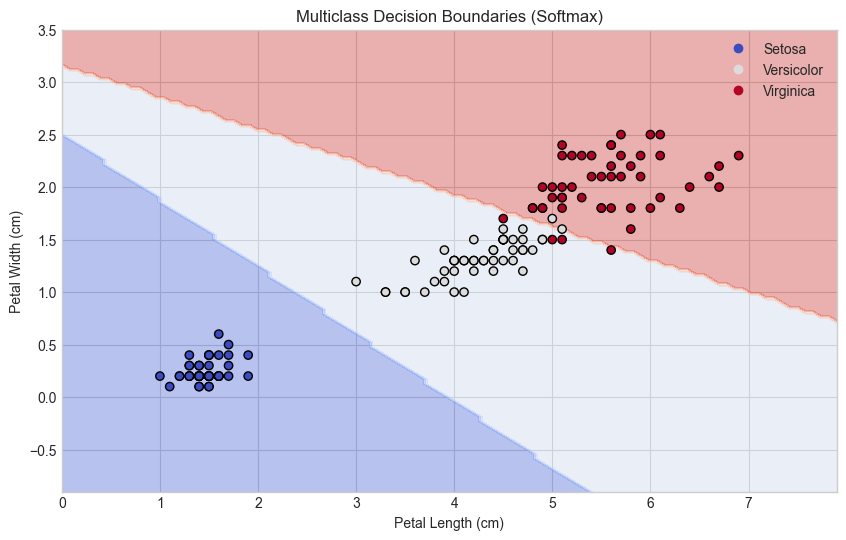

In [57]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
# 1. Isolate 2 Features
# We slice out only Petal Length and Petal Width to make it possible to draw a 2D graph
X_multi_2d = iris_df_full[['petal length (cm)', 'petal width (cm)']]
# 2. Create and fit pipeline
# Make a fresh new pipeline just for this 2D boundary drawing
multi_pipeline_2d = Pipeline([
    # Scale the 2 features
    ('scaler', StandardScaler()),
    
    # Train a multinomial-style Logistic Regression for graphing
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])
# Train it on the 2D data
multi_pipeline_2d.fit(X_multi_2d, y_multi)
# 3. Plotting
# Create a blank canvas of size 10x6 inches
plt.figure(figsize=(10, 6))
# Use scikit-learn's built-in DecisionBoundaryDisplay to color the background areas
disp = DecisionBoundaryDisplay.from_estimator(
    multi_pipeline_2d,          # The trained pipeline
    X_multi_2d,                 # The 2D feature matrix
    response_method="predict",  # Tell it to color based on hard predictions (0, 1, or 2)
    cmap=plt.cm.coolwarm,       # Use a red/blue color map
    alpha=0.4,                  # Make the background coloring semi-transparent
    ax=plt.gca()                # Draw this onto the current active canvas
)
# Overlay the real actual data points as solid dots on top of the shaded background
scatter = plt.scatter(X_multi_2d['petal length (cm)'], X_multi_2d['petal width (cm)'], 
                      c=y_multi, cmap=plt.cm.coolwarm, edgecolors='k')
# Add the main title at the top
plt.title("Multiclass Decision Boundaries (Softmax)")
# Label the horizontal X axis
plt.xlabel("Petal Length (cm)")
# Label the vertical Y axis
plt.ylabel("Petal Width (cm)")
# Extract the colors used in the scatter plot and create a legend showing the 3 actual flower names
plt.legend(handles=scatter.legend_elements()[0], labels=['Setosa', 'Versicolor', 'Virginica'])
# Command to actually render and show the final graphic
plt.show()


---
## ✅ Practical checklist (things to keep in mind)

- **Scaling matters**: with regularization (L1/L2), feature scale changes the penalty, so `StandardScaler()` is usually a must.
- **Data leakage**: fit scalers/encoders **only on train**, not on the full dataset (use a `Pipeline`).
- **Class imbalance**:
  - Don’t trust accuracy alone.
  - Consider `class_weight='balanced'`, different thresholds, and PR-AUC.
- **Pick the right metric**:
  - Accuracy for balanced/simple cases.
  - Precision/Recall/F1 for asymmetric costs.
  - ROC-AUC for ranking ability.
  - **Log-loss** for probability quality.
- **Threshold is a business decision**: `predict()` uses 0.5, but your best threshold depends on the cost of FP vs FN.
- **Perfect separation can happen** (like Iris 0 vs 1 here): it makes metrics look perfect; real-world data is rarely that clean.
- **Convergence warnings**: if you see them, increase `max_iter`, scale features, or change solver.
